In [2]:
import sys
print(sys.executable)

c:\CosmicID\venv\Scripts\python.exe


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the dataset
file_path = '../data/raw/sdss_stellar_classification.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 100000 rows, 18 columns


C:\Users\sdas_\AppData\Local\Temp\ipykernel_19416\2074482092.py:3: DtypeWarning: Columns (0: alpha, 1: run_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [5]:
# View first 5 rows
df.head()

,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
0,1.240000e+18,135.6891066,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.540000e+18,0.634794,5812,56354,171,GALAXY
1,1.240000e+18,144.8261006,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.180000e+19,0.779136,10445,58158,427,GALAXY
2,1.240000e+18,142.1887896,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.150000e+18,0.644195,4576,55592,299,GALAXY
3,1.240000e+18,338.7410378,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030000e+19,0.932346,9149,58039,775,GALAXY
4,1.240000e+18,345.2825932,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,NaN,301,3,137,6.890000e+18,0.116123,6121,56187,842,GALAXY


In [6]:
# View last 5 rows
df.tail()

,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
99995,1.240000e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.060000e+19,0.000000,9374,57749,438,GALAXY
99996,1.240000e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.590000e+18,0.404895,7626,56934,866,GALAXY
99997,1.240000e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.110000e+18,0.143366,2764,54535,74,GALAXY
99998,1.240000e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.600000e+18,0.455040,6751,56368,470,GALAXY
99999,1.240000e+18,196.896053,49.464643,22.62171,21.79745,20.60115,20.00959,19.28075,3650,301,4,60,8.340000e+18,0.542944,7410,57104,851,GALAXY


In [7]:
# Get basic info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   object_ID       100000 non-null  float64
 1   alpha           99999 non-null   object 
 2   delta           99998 non-null   float64
 3   UV_filter       100000 non-null  float64
 4   green_filter    100000 non-null  float64
 5   red_filter      100000 non-null  float64
 6   near_IR_filter  100000 non-null  float64
 7   IR_filter       100000 non-null  float64
 8   run_ID          99994 non-null   object 
 9   rerun_ID        100000 non-null  int64  
 10  cam_col         100000 non-null  int64  
 11  field_ID        100000 non-null  int64  
 12  spec_obj_ID     100000 non-null  float64
 13  red_shift       100000 non-null  float64
 14  plate_ID        100000 non-null  int64  
 15  MJD             100000 non-null  int64  
 16  fiber_ID        100000 non-null  int64  
 17  class           100000

In [8]:
# Check class distribution
print(df['class'].value_counts())

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


In [9]:
# Check for missing values
df.isnull().sum()

object_ID         0
alpha             1
delta             2
UV_filter         0
green_filter      0
red_filter        0
near_IR_filter    0
IR_filter         0
run_ID            6
rerun_ID          0
cam_col           0
field_ID          0
spec_obj_ID       0
red_shift         0
plate_ID          0
MJD               0
fiber_ID          0
class             0
dtype: int64

In [10]:
# Statistical summary of numeric columns
df.describe()

,object_ID,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID
count,1.000000e+05,99998.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.240000e+18,24.134955,21.980468,20.531387,19.645762,19.084854,18.668810,301.0,3.511610,186.130520,5.783925e+18,0.576661,5137.009660,55588.647500,449.312740
std,0.000000e+00,19.644480,31.769291,31.750292,1.854760,1.757895,31.728152,0.0,1.586912,149.011073,3.324007e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.240000e+18,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,301.0,1.000000,11.000000,3.000000e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.240000e+18,5.146668,20.352353,18.965230,18.135828,17.732285,17.460677,301.0,2.000000,82.000000,2.840000e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.240000e+18,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,301.0,4.000000,146.000000,5.610000e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.240000e+18,39.901442,23.687440,22.123767,21.044785,20.396495,19.921120,301.0,5.000000,241.000000,8.330000e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.240000e+18,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,301.0,6.000000,989.000000,1.410000e+19,7.011245,12547.000000,58932.000000,1000.000000


In [11]:
# Check the problematic columns more closely
print("Unique values in alpha (first 10):", df['alpha'].unique()[:10])
print("Unique values in run_ID (first 10):", df['run_ID'].unique()[:10])

Unique values in alpha (first 10): ['135.6891066' '144.8261006' '142.1887896' '338.7410378' '345.2825932'
 '340.9951205' '23.23492643' '5.433176037' '200.2904754' '39.1496906']
Unique values in run_ID (first 10): ['3606' '4518' '4192' nan '8102' '7773' '3716' '5934' '3927' '8157']


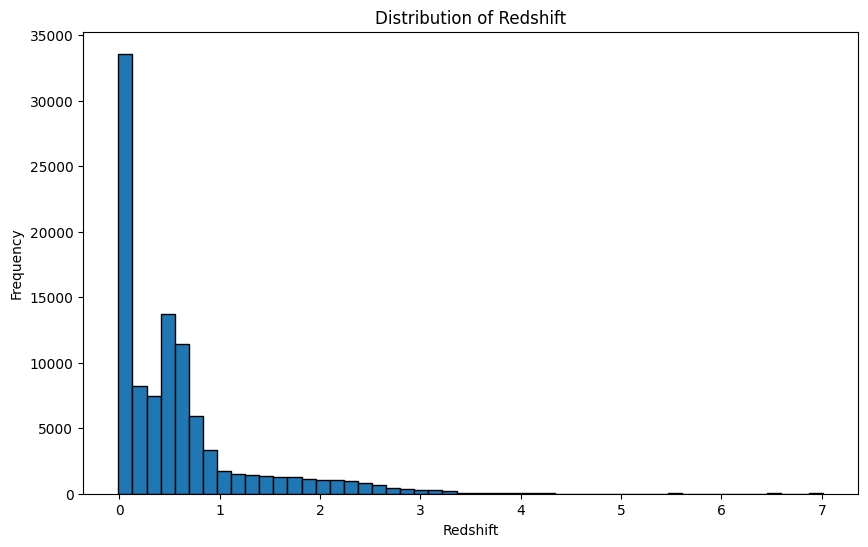

In [12]:
# Quick histogram of redshift
plt.figure(figsize=(10, 6))
plt.hist(df['red_shift'], bins=50, edgecolor='black')
plt.xlabel('Redshift')
plt.ylabel('Frequency')
plt.title('Distribution of Redshift')
plt.show()

In [13]:
# Check the -9999 values in magnitude columns
print("Rows with -9999 in UV_filter:", (df['UV_filter'] == -9999).sum())
print("Rows with -9999 in green_filter:", (df['green_filter'] == -9999).sum())
print("Rows with -9999 in IR_filter:", (df['IR_filter'] == -9999).sum())

Rows with -9999 in UV_filter: 1
Rows with -9999 in green_filter: 1
Rows with -9999 in IR_filter: 1
